# Tema 3 - Amplificadores de Una Etapa MOS

**Asignatura:** Electronica General - 2o GIERM

---

## Objetivos

1. **Comprender** las cuatro configuraciones basicas de amplificadores MOS con carga pasiva: CS, CD, CG y CM.
2. **Calcular** ganancia de tension ($A_v$), resistencia de entrada ($r_{in}$) y resistencia de salida ($r_{out}$) para cada configuracion.
3. **Comparar** cada configuracion con su amplificador ideal equivalente (tension, buffer, corriente, espejo).
4. **Analizar** el efecto de la carga activa y las combinaciones de etapas (cascode, buffer).

### Valores tipicos de referencia

| Parametro | Valor |
|-----------|-------|
| $g_{m1}$ | 1 mA/V |
| $g_{mb1}$ | 0.1 mA/V |
| $r_{o1}$ | 40 k$\Omega$ |
| $R_L$ | 5 k$\Omega$ |
| $V_{EFF}$ | 0.2 V |
| $I_D$ | 100 $\mu$A |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import schemdraw
import schemdraw.elements as elm

# Colores del tema
C_BLUE   = '#1f77b4'
C_ORANGE = '#ff7f0e'
C_GREEN  = '#2ca02c'
C_RED    = '#d62728'
C_PURPLE = '#9467bd'
C_GRAY   = '#7f7f7f'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Valores tipicos
gm1  = 1e-3      # 1 mA/V
gmb1 = 0.1e-3    # 0.1 mA/V
ro1  = 40e3       # 40 kohm
RL   = 5e3        # 5 kohm
VEFF = 0.2        # V
ID   = 100e-6     # 100 uA

print('Entorno cargado correctamente.')
print(f'gm1={gm1*1e3:.1f} mA/V, gmb1={gmb1*1e3:.1f} mA/V, ro1={ro1/1e3:.0f} kohm, RL={RL/1e3:.0f} kohm')

Entorno cargado correctamente.
gm1=1.0 mA/V, gmb1=0.1 mA/V, ro1=40 kohm, RL=5 kohm


## Formulario - Amplificadores de 1 Etapa MOS (Carga Pasiva)

| Config | $A_v$ | $r_{in}$ | $r_{out}$ | Tipo ideal |
|--------|-------|-----------|-----------|------------|
| **CS** (Source Comun) | $-g_{m1}(r_{o1} \| R_L)$ | $\infty$ | $r_{o1}$ | Amp. de tension |
| **CD** (Drain Comun) | $\dfrac{g_{m1}}{g_{m1}+g_{mb1}+\frac{1}{r_{o1}}+\frac{1}{R_L}} \approx 1$ | $\infty$ | $\dfrac{1}{g_{m1}+g_{mb1}+\frac{1}{r_{o1}}}$ | Buffer de tension |
| **CG** (Gate Comun) | $\dfrac{r_{in}}{r_{in}+R_S}(g_{m1}+g_{mb1}+\frac{1}{r_{o1}})(r_{o1} \| R_L)$ | $\dfrac{1}{g_{m1}+g_{mb1}+\frac{1}{r_{o1}}}\left(1+\frac{R_L}{r_{o1}}\right)$ | $r_{o1}+[1+(g_{m1}+g_{mb1})r_{o1}]R_S$ | Amp. de corriente |
| **CM** (Espejo) | -- | $\dfrac{1}{g_{m1}+\frac{1}{r_{o1}}} \approx \frac{1}{g_{m1}}$ | $r_{o2}$ | Espejo de corriente |

> **Nota:** En CG, $r_{out}$ exhibe el **efecto cascode**: la resistencia de salida se amplifica por $(g_m r_o)$, lo que resulta en valores muy altos.

In [2]:
# Calculo numerico de las formulas con valores tipicos
print('=' * 60)
print('VALORES NUMERICOS CON PARAMETROS TIPICOS')
print('=' * 60)

# CS
ro1_par_RL = (ro1 * RL) / (ro1 + RL)
Av_CS = -gm1 * ro1_par_RL
rin_CS = np.inf
rout_CS = ro1
print(f'\n--- CS (Source Comun) ---')
print(f'  ro1 || RL = {ro1_par_RL/1e3:.3f} kohm')
print(f'  Av  = {Av_CS:.3f}')
print(f'  rin = infinito (puerta MOS)')
print(f'  rout = {rout_CS/1e3:.0f} kohm')

# CD
Av_CD = gm1 / (gm1 + gmb1 + 1/ro1 + 1/RL)
rout_CD = 1 / (gm1 + gmb1 + 1/ro1)
print(f'\n--- CD (Drain Comun / Source Follower) ---')
print(f'  Av   = {Av_CD:.4f}')
print(f'  rin  = infinito (puerta MOS)')
print(f'  rout = {rout_CD/1e3:.3f} kohm')

# CG (con RS = 100 ohm)
RS_cg = 100
rin_CG = (1 / (gm1 + gmb1 + 1/ro1)) * (1 + RL/ro1)
rout_CG = ro1 + (1 + (gm1 + gmb1) * ro1) * RS_cg
Av_CG = (rin_CG / (rin_CG + RS_cg)) * (gm1 + gmb1 + 1/ro1) * ro1_par_RL
print(f'\n--- CG (Gate Comun) con RS = {RS_cg} ohm ---')
print(f'  rin  = {rin_CG/1e3:.3f} kohm')
print(f'  rout = {rout_CG/1e3:.1f} kohm (efecto cascode!)')
print(f'  Av   = {Av_CG:.3f}')

# CM
rin_CM = 1 / (gm1 + 1/ro1)
rout_CM = ro1  # ro2 = ro1 si mismo transistor
print(f'\n--- CM (Espejo de Corriente) ---')
print(f'  rin  = {rin_CM/1e3:.3f} kohm = 1/gm1 aprox {1/gm1/1e3:.3f} kohm')
print(f'  rout = {rout_CM/1e3:.0f} kohm')

VALORES NUMERICOS CON PARAMETROS TIPICOS

--- CS (Source Comun) ---
  ro1 || RL = 4.444 kohm
  Av  = -4.444
  rin = infinito (puerta MOS)
  rout = 40 kohm

--- CD (Drain Comun / Source Follower) ---
  Av   = 0.7547
  rin  = infinito (puerta MOS)
  rout = 0.889 kohm

--- CG (Gate Comun) con RS = 100 ohm ---
  rin  = 1.000 kohm
  rout = 44.5 kohm (efecto cascode!)
  Av   = 4.545

--- CM (Espejo de Corriente) ---
  rin  = 0.976 kohm = 1/gm1 aprox 1.000 kohm
  rout = 40 kohm


---

## 1. CS - Source Comun (Common Source)

El amplificador **CS** es la configuracion mas comun. Funciona como **amplificador de tension inversor**.

**Caracteristicas clave:**
- **Ganancia de tension** $A_v = -g_{m1}(r_{o1} \| R_L)$ (negativa = inversora)
- **Resistencia de entrada** $r_{in} = \infty$ (puerta MOS aislada)
- **Resistencia de salida** $r_{out} = r_{o1}$
- Analogia: equivalente al **emisor comun** (EC) en BJT

**Aplicacion:** Etapa de ganancia de tension en amplificadores multietapa.

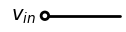

AttributeError: module 'schemdraw.elements' has no attribute 'MosfetN'

In [3]:
# Circuito CS - Source Comun
with schemdraw.Drawing() as d:
    d.config(fontsize=14)

    # Entrada
    d += elm.Dot(open=True).label('$v_{in}$', 'left')
    d += elm.Line().right(1.5)

    # Transistor NMOS
    M = d.add(elm.MosfetN().right().anchor('gate').label('$M_1$', 'right'))

    # VDD arriba
    d += elm.Line().at(M.drain).up(1)
    d += elm.Resistor().up().label('$R_L$', 'right')
    d += elm.Line().up(0.5)
    d += elm.Dot(open=True).label('$V_{DD}$', 'top')

    # Salida
    d += elm.Line().at(M.drain).right(2)
    d += elm.Dot(open=True).label('$v_{out}$', 'right')

    # Ground
    d += elm.Line().at(M.source).down(0.5)
    d += elm.Ground()

In [ ]:
# Modelo pequena senal CS
with schemdraw.Drawing() as d:
    d.config(fontsize=13)

    # Entrada vgs
    d += elm.Dot(open=True).label('$v_{in}$', 'left')
    d += elm.Line().right(1)
    vin_node = d.here

    # vgs arriba-abajo
    d += elm.Line().down(2)
    gnd_left = d.here
    d += elm.Ground()

    # Fuente de corriente gm*vgs
    d += elm.Line().at(vin_node).right(3)
    top_mid = d.here
    d += elm.SourceI().down(2).label('$g_m v_{gs}$', 'right').reverse()
    bot_mid = d.here

    # ro en paralelo
    d += elm.Line().at(top_mid).right(2.5)
    top_ro = d.here
    d += elm.Resistor().down(2).label('$r_o$', 'right')
    bot_ro = d.here

    # RL
    d += elm.Line().at(top_ro).right(2.5)
    top_rl = d.here
    d += elm.Resistor().down(2).label('$R_L$', 'right')
    bot_rl = d.here

    # vout
    d += elm.Line().at(top_rl).right(1)
    d += elm.Dot(open=True).label('$v_{out}$', 'right')

    # Conectar grounds
    d += elm.Line().at(bot_mid).to(bot_ro)
    d += elm.Line().at(bot_ro).to(bot_rl)

print('Modelo pequena senal CS:')
print('  vgs entre Gate y Source (GND)')
print('  Fuente dependiente: gm*vgs (drain a source)')
print('  ro en paralelo con RL')
print(f'\n  Av = -gm*(ro||RL) = -{gm1*1e3:.0f}m * {ro1_par_RL/1e3:.2f}k = {-gm1*ro1_par_RL:.3f}')

### Comparacion CS vs Amplificador de Tension Ideal

| Parametro | Ideal | CS Real |
|-----------|-------|--------|
| $A_v$ | $-\infty$ (finito con realim.) | $-g_{m1}(r_{o1} \| R_L) \approx -4.44$ |
| $r_{in}$ | $\infty$ | $\infty$ (cumple!) |
| $r_{out}$ | $0$ | $r_{o1} = 40\ \text{k}\Omega$ (no cumple) |
| Inversion | Si | Si |

> El CS tiene $r_{in}$ ideal pero $r_{out}$ alta. Para reducir $r_{out}$ se anade una etapa **CD** (buffer) a la salida.

---

## 2. CD - Drain Comun (Common Drain / Source Follower)

El amplificador **CD** es un **buffer de tension** (seguidor de source).

**Caracteristicas clave:**
- **Ganancia de tension** $A_v = \dfrac{g_{m1}}{g_{m1}+g_{mb1}+\frac{1}{r_{o1}}+\frac{1}{R_L}} \approx 1$ (no inversora)
- **Resistencia de entrada** $r_{in} = \infty$
- **Resistencia de salida** $r_{out} = \dfrac{1}{g_{m1}+g_{mb1}+\frac{1}{r_{o1}}} \approx 0.889\ \text{k}\Omega$
- Analogia: equivalente al **colector comun** (CC) en BJT

**Aplicacion:** Etapa de salida para reducir la impedancia de salida de otra etapa.

In [ ]:
# Circuito CD - Drain Comun (Source Follower)
with schemdraw.Drawing() as d:
    d.config(fontsize=14)

    # Entrada
    d += elm.Dot(open=True).label('$v_{in}$', 'left')
    d += elm.Line().right(1.5)

    # Transistor NMOS
    M = d.add(elm.MosfetN().right().anchor('gate').label('$M_1$', 'right'))

    # VDD arriba (drain directo)
    d += elm.Line().at(M.drain).up(1)
    d += elm.Dot(open=True).label('$V_{DD}$', 'top')

    # Source -> RL -> GND
    d += elm.Line().at(M.source).down(0.5)
    src_node = d.here
    d += elm.Resistor().down().label('$R_L$', 'right')
    d += elm.Ground()

    # Salida en source
    d += elm.Line().at(src_node).right(2)
    d += elm.Dot(open=True).label('$v_{out}$', 'right')

In [ ]:
# Modelo pequena senal CD
with schemdraw.Drawing() as d:
    d.config(fontsize=13)

    # Entrada
    d += elm.Dot(open=True).label('$v_{in} = v_{gs} + v_{out}$', 'left')
    d += elm.Line().right(1.5)
    gate_node = d.here

    # Fuente gm*vgs
    d += elm.Line().right(2.5)
    top_gm = d.here
    d += elm.SourceI().down(2).label('$g_m v_{gs}$', 'left').reverse()
    bot_gm = d.here

    # gmb*vbs
    d += elm.Line().at(top_gm).right(2)
    top_gmb = d.here
    d += elm.SourceI().down(2).label('$g_{mb} v_{bs}$', 'left').reverse()
    bot_gmb = d.here

    # ro
    d += elm.Line().at(top_gmb).right(2)
    top_ro = d.here
    d += elm.Resistor().down(2).label('$r_o$', 'right')
    bot_ro = d.here

    # RL
    d += elm.Line().at(top_ro).right(2)
    top_rl = d.here
    d += elm.Resistor().down(2).label('$R_L$', 'right')
    bot_rl = d.here

    # vout label
    d += elm.Line().at(top_rl).right(1)
    d += elm.Dot(open=True).label('$v_{out}$', 'right')

    # Connections
    d += elm.Line().at(bot_gm).to(bot_gmb)
    d += elm.Line().at(bot_gmb).to(bot_ro)
    d += elm.Line().at(bot_ro).to(bot_rl)
    d += elm.Line().at(bot_rl).right(0.5)
    d += elm.Ground()

Av_CD_val = gm1 / (gm1 + gmb1 + 1/ro1 + 1/RL)
rout_CD_val = 1 / (gm1 + gmb1 + 1/ro1)
print('Modelo pequena senal CD:')
print(f'  Av   = gm/(gm+gmb+1/ro+1/RL) = {Av_CD_val:.4f} (cercano a 1)')
print(f'  rout = 1/(gm+gmb+1/ro) = {rout_CD_val:.2f} ohm = {rout_CD_val/1e3:.3f} kohm')
print(f'  rin  = infinito')

### Comparacion CD vs Buffer de Tension Ideal

| Parametro | Ideal | CD Real |
|-----------|-------|--------|
| $A_v$ | $1$ | $\approx 0.83$ (con $g_{mb}$) |
| $r_{in}$ | $\infty$ | $\infty$ (cumple!) |
| $r_{out}$ | $0$ | $\approx 889\ \Omega$ (mucho menor que CS) |
| Inversion | No | No (cumple!) |

> El efecto de body ($g_{mb}$) reduce ligeramente la ganancia. Sin body effect: $A_v \to 1$.

---

## 3. CG - Gate Comun (Common Gate)

El amplificador **CG** es un **amplificador de corriente** (baja $r_{in}$, alta $r_{out}$).

**Caracteristicas clave:**
- **Ganancia de tension** $A_v = \dfrac{r_{in}}{r_{in}+R_S}\left(g_{m1}+g_{mb1}+\dfrac{1}{r_{o1}}\right)(r_{o1} \| R_L)$
- **Resistencia de entrada** $r_{in} = \dfrac{1}{g_{m1}+g_{mb1}+\frac{1}{r_{o1}}}\left(1+\dfrac{R_L}{r_{o1}}\right)$
- **Resistencia de salida** $r_{out} = r_{o1} + [1+(g_{m1}+g_{mb1})r_{o1}]R_S \approx (g_m r_o) R_S$ (**efecto cascode**)
- Analogia: equivalente a la **base comun** (BC) en BJT

**Aplicacion:** Segunda etapa en configuraciones **cascode** (CS + CG) para aumentar $r_{out}$ drasticamente.

In [ ]:
# Circuito CG - Gate Comun
with schemdraw.Drawing() as d:
    d.config(fontsize=14)

    # Source del transistor (entrada)
    d += elm.Dot(open=True).label('$v_{in}$', 'left')
    d += elm.Line().right(1)
    d += elm.Resistor().right().label('$R_S$', 'top')
    d += elm.Line().right(0.5)

    # Transistor NMOS
    M = d.add(elm.MosfetN().right().anchor('source').label('$M_1$', 'right'))

    # Gate a ground (VG = cte)
    d += elm.Line().at(M.gate).left(1)
    d += elm.Dot(open=True).label('$V_G$', 'left')

    # Drain -> RL -> VDD
    d += elm.Line().at(M.drain).up(0.5)
    drain_node = d.here
    d += elm.Resistor().up().label('$R_L$', 'right')
    d += elm.Line().up(0.5)
    d += elm.Dot(open=True).label('$V_{DD}$', 'top')

    # Salida en drain
    d += elm.Line().at(drain_node).right(2)
    d += elm.Dot(open=True).label('$v_{out}$', 'right')

In [ ]:
# Modelo pequena senal CG
with schemdraw.Drawing() as d:
    d.config(fontsize=13)

    # RS desde vin
    d += elm.Dot(open=True).label('$v_{in}$', 'left')
    d += elm.Resistor().right().label('$R_S$', 'top')
    src_node = d.here

    # Fuente gm*vgs (vgs = -vs ya que vg = 0 en AC)
    d += elm.Line().right(1.5)
    top_gm = d.here
    d += elm.SourceI().down(2).label('$g_m v_{gs}$', 'right').reverse()
    bot_gm = d.here

    # gmb*vbs
    d += elm.Line().at(top_gm).right(2)
    top_gmb = d.here
    d += elm.SourceI().down(2).label('$g_{mb} v_{bs}$', 'right').reverse()
    bot_gmb = d.here

    # ro
    d += elm.Line().at(top_gmb).right(2)
    top_ro = d.here
    d += elm.Resistor().down(2).label('$r_o$', 'right')
    bot_ro = d.here

    # RL
    d += elm.Line().at(top_ro).right(2)
    top_rl = d.here
    d += elm.Resistor().down(2).label('$R_L$', 'right')
    bot_rl = d.here

    # vout
    d += elm.Line().at(top_rl).right(1)
    d += elm.Dot(open=True).label('$v_{out}$', 'right')

    # Ground connections
    d += elm.Line().at(bot_gm).to(bot_gmb)
    d += elm.Line().at(bot_gmb).to(bot_ro)
    d += elm.Line().at(bot_ro).to(bot_rl)

RS = 100
rin_CG_val = (1 / (gm1 + gmb1 + 1/ro1)) * (1 + RL/ro1)
rout_CG_val = ro1 + (1 + (gm1 + gmb1) * ro1) * RS
Av_CG_val = (rin_CG_val / (rin_CG_val + RS)) * (gm1 + gmb1 + 1/ro1) * (ro1*RL/(ro1+RL))
print('Modelo pequena senal CG (RS = 100 ohm):')
print(f'  rin  = {rin_CG_val:.2f} ohm = {rin_CG_val/1e3:.3f} kohm')
print(f'  rout = {rout_CG_val/1e3:.1f} kohm (EFECTO CASCODE)')
print(f'  Av   = {Av_CG_val:.3f}')
print(f'\n  Nota: rout >> ro gracias al factor (gm*ro)*RS = {(gm1*ro1)*RS/1e3:.0f} kohm')

### Comparacion CG vs Amplificador de Corriente Ideal

| Parametro | Ideal | CG Real |
|-----------|-------|--------|
| $A_v$ | $\dfrac{R_L}{R_S}$ | Depende de $g_m$, $r_o$ |
| $r_{in}$ | $0$ | $\approx 1\ \text{k}\Omega$ (baja, cercano a ideal) |
| $r_{out}$ | $\infty$ | $\approx 4.5\ \text{M}\Omega$ (muy alta, efecto cascode!) |
| Inversion | No | No (cumple!) |

> **Efecto cascode:** $r_{out} \approx (g_m r_o) R_S$. Con $g_m r_o = 40$, la resistencia de salida se multiplica por 40 respecto a $r_{o1}$ solo.

---

## 4. CM - Espejo de Corriente (Current Mirror)

El **espejo de corriente** copia la corriente de referencia a la salida con alta impedancia.

**Caracteristicas clave:**
- **Ganancia de corriente** $A_i = \dfrac{g_{m2}}{g_{m1}+\frac{1}{r_{o1}}} \cdot \dfrac{r_{o2} \| R_L}{R_L}$
- **Resistencia de entrada** $r_{in} = \dfrac{1}{g_{m1}+\frac{1}{r_{o1}}} \approx \dfrac{1}{g_{m1}}$
- **Resistencia de salida** $r_{out} = r_{o2}$
- Si $M_1 = M_2$ (mismas dimensiones): $A_i \approx 1$

**Aplicacion:** Fuente de corriente, carga activa, referencia de polarizacion.

In [ ]:
# Circuito CM - Espejo de Corriente
with schemdraw.Drawing() as d:
    d.config(fontsize=14)

    # M1 (referencia) - lado izquierdo
    d += elm.Dot(open=True).label('$I_{ref}$', 'top')
    d += elm.Line().down(1)
    m1_drain = d.here

    M1 = d.add(elm.MosfetN().anchor('drain').label('$M_1$', 'left').flip())

    # Gate-drain M1 conectados (diode-connected)
    d += elm.Line().at(M1.gate).left(0.5)
    d += elm.Line().up(1.5)
    d += elm.Line().right(0.5)

    # M1 source a GND
    d += elm.Line().at(M1.source).down(0.5)
    m1_gnd = d.here
    d += elm.Ground()

    # M2 (salida) - lado derecho
    d += elm.Line().at(M1.gate).right(3)
    m2_gate = d.here

    M2 = d.add(elm.MosfetN().anchor('gate').label('$M_2$', 'right'))

    # M2 drain -> salida
    d += elm.Line().at(M2.drain).up(1)
    d += elm.Dot(open=True).label('$I_{out}$', 'top')

    # M2 source a GND
    d += elm.Line().at(M2.source).down(0.5)
    d += elm.Ground()

In [ ]:
# Analisis del espejo de corriente
rin_CM_val = 1 / (gm1 + 1/ro1)
rout_CM_val = ro1  # ro2 ~ ro1 si mismos transistores
gm2 = gm1  # Mismas dimensiones

Ai_CM = (gm2 / (gm1 + 1/ro1)) * (ro1 * RL / (ro1 + RL)) / RL
print('Analisis Espejo de Corriente:')
print(f'  rin  = 1/(gm1 + 1/ro1) = {rin_CM_val:.2f} ohm = {rin_CM_val/1e3:.3f} kohm')
print(f'  rout = ro2 = {rout_CM_val/1e3:.0f} kohm')
print(f'  Ai   = {Ai_CM:.4f} (cercano a 1 si M1 = M2)')
print(f'\n  Precision del espejo: Iout/Iref = gm2/gm1 * ro2||(RL) / RL')
print(f'  Error por ro finito: {(1 - Ai_CM)*100:.2f}%')

### Comparacion CM vs Espejo de Corriente Ideal

| Parametro | Ideal | CM Real |
|-----------|-------|--------|
| $A_i$ | $1$ (copia exacta) | $\approx 0.997$ (error por $r_o$ finito) |
| $r_{in}$ | $0$ | $\approx 1/g_{m1} = 1\ \text{k}\Omega$ |
| $r_{out}$ | $\infty$ | $r_{o2} = 40\ \text{k}\Omega$ |

> Para mejorar $r_{out}$ se usa el espejo **cascode**: se anade un CG en la salida.

---

## 5. Carga Activa vs Carga Pasiva

| Aspecto | Carga Pasiva ($R_L$) | Carga Activa (Espejo PMOS) |
|---------|---------------------|---------------------------|
| **Ganancia CS** | $-g_m(r_{o1} \| R_L)$ | $-g_m(r_{o1} \| r_{o2})$ |
| **Valor tipico** | $\approx -4.4$ | $\approx -20$ (mucho mayor!) |
| **Caida de tension** | $I_D \cdot R_L$ (problemas de headroom) | Minima ($V_{EFF}$) |
| **Consumo** | Potencia en resistencia | Solo corriente de polarizacion |
| **Area en IC** | Resistencias grandes | Transistores pequenos |

> **En circuitos integrados siempre se usa carga activa.** La carga pasiva solo se usa en circuitos discretos o para simplificar el analisis.

In [ ]:
# Comparacion grafica: ganancia con carga pasiva vs activa
RL_range = np.linspace(1e3, 100e3, 200)
ro2_active = 40e3  # ro del transistor PMOS de carga

# Ganancia con carga pasiva
Av_passive = gm1 * (ro1 * RL_range) / (ro1 + RL_range)

# Ganancia con carga activa (ro2 fijo)
Av_active = gm1 * (ro1 * ro2_active) / (ro1 + ro2_active) * np.ones_like(RL_range)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(RL_range/1e3, Av_passive, color=C_BLUE, linewidth=2,
        label='Carga pasiva: $|A_v| = g_m(r_o \\| R_L)$')
ax.axhline(y=Av_active[0], color=C_RED, linewidth=2, linestyle='--',
           label=f'Carga activa: $|A_v| = g_m(r_{{o1}} \\| r_{{o2}}) = {Av_active[0]:.1f}$')
ax.axhline(y=gm1*ro1, color=C_GRAY, linewidth=1, linestyle=':',
           label=f'Limite: $g_m \\cdot r_o = {gm1*ro1:.0f}$')

ax.set_xlabel('$R_L$ (k$\\Omega$)')
ax.set_ylabel('$|A_v|$')
ax.set_title('Ganancia CS: Carga Pasiva vs Activa')
ax.legend(fontsize=11)
ax.set_ylim(0, 45)
plt.tight_layout()
plt.show()

---

## 6. Combinaciones de Etapas

### 6.1 Cascode (CS + CG)

Apila un CS y un CG para obtener **altisima resistencia de salida**:

$$r_{out,cascode} = (g_m r_o)^2 \cdot R_S \quad \text{(telescopica)}$$

**Ventajas:**
- $r_{out}$ enormemente amplificada (efecto cascode al cuadrado)
- Mejor ganancia con carga activa: $A_v = -g_m \cdot [(g_m r_o) r_o \| (g_m r_o) r_o]$
- Menos efecto Miller

**Desventaja:** Reduce el rango de senal de salida (headroom).

### 6.2 CS + CD (Buffer de salida)

Anade un CD (source follower) a la salida del CS:

- **CS** proporciona la ganancia de tension
- **CD** reduce $r_{out}$ a $\approx 1/g_m$

$$A_v = A_{v,CS} \cdot A_{v,CD} \approx -g_m(r_o \| R_L) \cdot 1$$

**Aplicacion:** Cuando se necesita manejar cargas de baja impedancia.

In [ ]:
# Diagrama de bloques: combinaciones de etapas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cascode (CS + CG)
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.set_title('Cascode: CS + CG', fontsize=14, fontweight='bold')
ax.axis('off')

# Bloques
for x, label, color in [(1.5, 'CS\n$A_v, r_{out}=r_o$', C_BLUE),
                          (5.5, 'CG\n$r_{out} \\times g_m r_o$', C_GREEN)]:
    ax.add_patch(plt.Rectangle((x-1, 1), 2.5, 2, facecolor=color, alpha=0.3,
                                edgecolor=color, linewidth=2))
    ax.text(x+0.25, 2, label, ha='center', va='center', fontsize=11)

ax.annotate('', xy=(4.5, 2), xytext=(3.0, 2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(0, 2, '$v_{in}$', fontsize=13, ha='center', va='center')
ax.annotate('', xy=(1.0, 2), xytext=(0.3, 2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(8.5, 2, '$v_{out}$', fontsize=13, ha='center', va='center')
ax.annotate('', xy=(8.2, 2), xytext=(7.0, 2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(5, 0.5, '$r_{out} \\approx (g_m r_o)^2 R_S$', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# CS + CD (Buffer)
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.set_title('Buffer: CS + CD', fontsize=14, fontweight='bold')
ax.axis('off')

for x, label, color in [(1.5, 'CS\n$A_v \\approx -g_m R_L$', C_BLUE),
                          (5.5, 'CD\n$A_v \\approx 1$\n$r_{out} \\approx 1/g_m$', C_ORANGE)]:
    ax.add_patch(plt.Rectangle((x-1, 1), 2.5, 2, facecolor=color, alpha=0.3,
                                edgecolor=color, linewidth=2))
    ax.text(x+0.25, 2, label, ha='center', va='center', fontsize=11)

ax.annotate('', xy=(4.5, 2), xytext=(3.0, 2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(0, 2, '$v_{in}$', fontsize=13, ha='center', va='center')
ax.annotate('', xy=(1.0, 2), xytext=(0.3, 2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(8.5, 2, '$v_{out}$', fontsize=13, ha='center', va='center')
ax.annotate('', xy=(8.2, 2), xytext=(7.0, 2),
            arrowprops=dict(arrowstyle='->', lw=2))
ax.text(5, 0.5, '$r_{out,total} \\approx 1/g_m$ (baja)', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

---

## 7. Ejercicios Resueltos

### Ejercicio 1: Amplificador CS

**Datos:** $g_m = 2\ \text{mA/V}$, $r_o = 50\ \text{k}\Omega$, $R_L = 10\ \text{k}\Omega$

**Calcular:** $A_v$, $r_{in}$, $r_{out}$

In [ ]:
# Ejercicio 1: Amplificador CS
gm_e1 = 2e-3     # 2 mA/V
ro_e1 = 50e3      # 50 kohm
RL_e1 = 10e3      # 10 kohm

print('=' * 50)
print('EJERCICIO 1: Amplificador CS')
print('=' * 50)

# ro || RL
ro_par_RL_e1 = (ro_e1 * RL_e1) / (ro_e1 + RL_e1)
print(f'\n1) ro || RL = ({ro_e1/1e3:.0f}k * {RL_e1/1e3:.0f}k) / ({ro_e1/1e3:.0f}k + {RL_e1/1e3:.0f}k)')
print(f'           = {ro_par_RL_e1/1e3:.3f} kohm')

# Av
Av_e1 = -gm_e1 * ro_par_RL_e1
print(f'\n2) Av = -gm * (ro || RL)')
print(f'     = -{gm_e1*1e3:.0f}m * {ro_par_RL_e1/1e3:.3f}k')
print(f'     = {Av_e1:.3f}')

# rin
print(f'\n3) rin = infinito (puerta MOS aislada)')

# rout
print(f'\n4) rout = ro = {ro_e1/1e3:.0f} kohm')

print(f'\n--- Resumen ---')
print(f'  Av   = {Av_e1:.2f}')
print(f'  rin  = infinito')
print(f'  rout = {ro_e1/1e3:.0f} kohm')

### Ejercicio 2: Buffer CD (Source Follower)

**Datos:** $g_m = 1\ \text{mA/V}$, $g_{mb} = 0.1\ \text{mA/V}$, $r_o = 40\ \text{k}\Omega$, $R_L = 5\ \text{k}\Omega$

**Calcular:** $A_v$, $r_{out}$. Cuando se usa esta configuracion?

In [ ]:
# Ejercicio 2: Buffer CD
gm_e2 = 1e-3
gmb_e2 = 0.1e-3
ro_e2 = 40e3
RL_e2 = 5e3

print('=' * 50)
print('EJERCICIO 2: Buffer CD (Source Follower)')
print('=' * 50)

# Av
denom = gm_e2 + gmb_e2 + 1/ro_e2 + 1/RL_e2
Av_e2 = gm_e2 / denom
print(f'\n1) Denominador = gm + gmb + 1/ro + 1/RL')
print(f'   = {gm_e2*1e3:.1f}m + {gmb_e2*1e3:.1f}m + {1/ro_e2*1e3:.4f}m + {1/RL_e2*1e3:.1f}m')
print(f'   = {denom*1e3:.4f} mA/V')

print(f'\n2) Av = gm / denominador')
print(f'     = {gm_e2*1e3:.1f}m / {denom*1e3:.4f}m')
print(f'     = {Av_e2:.4f}')

# rout (sin RL)
rout_e2 = 1 / (gm_e2 + gmb_e2 + 1/ro_e2)
print(f'\n3) rout = 1 / (gm + gmb + 1/ro)')
print(f'       = 1 / ({(gm_e2 + gmb_e2 + 1/ro_e2)*1e3:.4f}m)')
print(f'       = {rout_e2:.2f} ohm = {rout_e2/1e3:.3f} kohm')

print(f'\n--- Resumen ---')
print(f'  Av   = {Av_e2:.4f} (cercano a 1 -> buffer)')
print(f'  rin  = infinito')
print(f'  rout = {rout_e2:.1f} ohm')
print(f'\n--- Cuando usar CD ---')
print(f'  - Como etapa de salida tras un CS para bajar rout')
print(f'  - Para manejar cargas de baja impedancia')
print(f'  - Cuando se necesita Av ~ 1 sin inversion')

### Ejercicio 3: Amplificador CG con efecto Cascode

**Datos:** $g_m = 1\ \text{mA/V}$, $g_{mb} = 0.1\ \text{mA/V}$, $r_o = 40\ \text{k}\Omega$, $R_S = 100\ \Omega$, $R_L = 5\ \text{k}\Omega$

**Calcular:** $r_{in}$, $r_{out}$ (demostrar efecto cascode), $A_v$

In [ ]:
# Ejercicio 3: Amplificador CG
gm_e3 = 1e-3
gmb_e3 = 0.1e-3
ro_e3 = 40e3
RS_e3 = 100
RL_e3 = 5e3

print('=' * 50)
print('EJERCICIO 3: Amplificador CG (Efecto Cascode)')
print('=' * 50)

# rin
base_conductance = gm_e3 + gmb_e3 + 1/ro_e3
rin_e3 = (1 / base_conductance) * (1 + RL_e3/ro_e3)
print(f'\n1) Conductancia base = gm + gmb + 1/ro')
print(f'   = {gm_e3*1e3:.1f}m + {gmb_e3*1e3:.1f}m + {1/ro_e3*1e6:.1f}u')
print(f'   = {base_conductance*1e3:.4f} mA/V')
print(f'\n   rin = (1/conductancia) * (1 + RL/ro)')
print(f'       = {1/base_conductance:.2f} * (1 + {RL_e3/1e3:.0f}k/{ro_e3/1e3:.0f}k)')
print(f'       = {1/base_conductance:.2f} * {1 + RL_e3/ro_e3:.4f}')
print(f'       = {rin_e3:.2f} ohm = {rin_e3/1e3:.3f} kohm')

# rout (EFECTO CASCODE)
rout_e3 = ro_e3 + (1 + (gm_e3 + gmb_e3) * ro_e3) * RS_e3
gm_ro_product = (gm_e3 + gmb_e3) * ro_e3
print(f'\n2) rout = ro + [1 + (gm + gmb)*ro] * RS')
print(f'       = {ro_e3/1e3:.0f}k + [1 + {gm_ro_product:.1f}] * {RS_e3}')
print(f'       = {ro_e3/1e3:.0f}k + {(1 + gm_ro_product)*RS_e3/1e3:.1f}k')
print(f'       = {rout_e3/1e3:.1f} kohm = {rout_e3/1e6:.3f} Mohm')
print(f'\n   EFECTO CASCODE: rout / ro = {rout_e3/ro_e3:.1f}x amplificacion!')
print(f'   Aprox: (gm*ro)*RS = {gm_e3*ro_e3*RS_e3/1e3:.0f} kohm')

# Av
ro_par_RL_e3 = (ro_e3 * RL_e3) / (ro_e3 + RL_e3)
Av_e3 = (rin_e3 / (rin_e3 + RS_e3)) * base_conductance * ro_par_RL_e3
print(f'\n3) Av = [rin/(rin+RS)] * conductancia * (ro||RL)')
print(f'     = [{rin_e3:.2f}/({rin_e3:.2f}+{RS_e3})] * {base_conductance*1e3:.4f}m * {ro_par_RL_e3/1e3:.3f}k')
print(f'     = {rin_e3/(rin_e3+RS_e3):.4f} * {base_conductance*ro_par_RL_e3:.4f}')
print(f'     = {Av_e3:.3f}')

### Ejercicio 4: Espejo de Corriente

**Datos:** $g_{m1} = g_{m2} = 1\ \text{mA/V}$, $r_{o1} = r_{o2} = 40\ \text{k}\Omega$, $R_L = 5\ \text{k}\Omega$

**Calcular:** $A_i$, $r_{in}$, $r_{out}$

In [ ]:
# Ejercicio 4: Espejo de Corriente
gm1_e4 = 1e-3
gm2_e4 = 1e-3
ro1_e4 = 40e3
ro2_e4 = 40e3
RL_e4 = 5e3

print('=' * 50)
print('EJERCICIO 4: Espejo de Corriente')
print('=' * 50)

# rin
rin_e4 = 1 / (gm1_e4 + 1/ro1_e4)
print(f'\n1) rin = 1 / (gm1 + 1/ro1)')
print(f'      = 1 / ({gm1_e4*1e3:.1f}m + {1/ro1_e4*1e6:.1f}u)')
print(f'      = {rin_e4:.2f} ohm = {rin_e4/1e3:.3f} kohm')
print(f'      Aprox 1/gm1 = {1/gm1_e4:.0f} ohm = {1/gm1_e4/1e3:.0f} kohm')

# rout
rout_e4 = ro2_e4
print(f'\n2) rout = ro2 = {rout_e4/1e3:.0f} kohm')

# Ai
ro2_par_RL = (ro2_e4 * RL_e4) / (ro2_e4 + RL_e4)
Ai_e4 = (gm2_e4 / (gm1_e4 + 1/ro1_e4)) * (ro2_par_RL / RL_e4)
print(f'\n3) Ai = [gm2 / (gm1 + 1/ro1)] * [(ro2 || RL) / RL]')
print(f'      = [{gm2_e4*1e3:.1f}m / {(gm1_e4 + 1/ro1_e4)*1e3:.4f}m] * [{ro2_par_RL/1e3:.3f}k / {RL_e4/1e3:.0f}k]')
print(f'      = {gm2_e4/(gm1_e4+1/ro1_e4):.4f} * {ro2_par_RL/RL_e4:.4f}')
print(f'      = {Ai_e4:.4f}')

print(f'\n--- Resumen ---')
print(f'  Ai   = {Ai_e4:.4f} (ideal = 1)')
print(f'  rin  = {rin_e4:.1f} ohm')
print(f'  rout = {rout_e4/1e3:.0f} kohm')
print(f'  Error de copia: {(1-Ai_e4)*100:.2f}%')

---

## 8. Catalogo de Ejercicios

| # | Tipo | Descripcion | Dificultad |
|---|------|-------------|------------|
| 1 | **CS basico** | Calcular $A_v$, $r_{in}$, $r_{out}$ dados $g_m$, $r_o$, $R_L$ | Baja |
| 2 | **CD buffer** | Calcular $A_v$, $r_{out}$ incluyendo efecto body ($g_{mb}$) | Baja |
| 3 | **CG cascode** | Demostrar efecto cascode en $r_{out}$, calcular $A_v$ | Media |
| 4 | **CM espejo** | Calcular $A_i$, error de copia, $r_{in}$, $r_{out}$ | Media |
| 5 | **CS + CD** | Calcular parametros de amplificador de 2 etapas con buffer | Media-Alta |
| 6 | **Cascode completo** | CS + CG con carga activa cascode, calcular $r_{out}$, $A_v$ | Alta |

### Metodologia general de resolucion

1. **Identificar** la configuracion (CS, CD, CG, CM)
2. **Dibujar** el modelo de pequena senal (fuentes $g_m v_{gs}$, $g_{mb} v_{bs}$, $r_o$)
3. **Aplicar** las formulas del formulario
4. **Verificar** coherencia: CS invierte, CD no invierte, CG baja $r_{in}$, etc.

---

## 9. Tabla Resumen Comparativa

| | **CS** | **CD** | **CG** | **CM** |
|---|--------|--------|--------|--------|
| **Funcion** | Amp. tension | Buffer tension | Amp. corriente | Espejo corriente |
| **$A_v$** | $-g_m(r_o \| R_L)$ | $\approx 1$ | Depende de $R_S$ | -- |
| **$r_{in}$** | $\infty$ | $\infty$ | $\approx 1/g_m$ (baja) | $\approx 1/g_m$ |
| **$r_{out}$** | $r_o$ (alta) | $\approx 1/g_m$ (baja) | $(g_m r_o) R_S$ (muy alta) | $r_o$ |
| **Invierte** | Si | No | No | -- |
| **Uso tipico** | Ganancia | Etapa salida | Cascode | Polarizacion |
| **Equivalente BJT** | EC | CC | BC | Espejo BJT |

### Reglas rapidas de diseno

- **Necesitas ganancia?** $\to$ CS
- **Necesitas baja impedancia de salida?** $\to$ CD (buffer)
- **Necesitas alta impedancia de salida?** $\to$ CG (cascode)
- **Necesitas copiar corriente?** $\to$ CM (espejo)
- **Necesitas ganancia + baja rout?** $\to$ CS + CD
- **Necesitas ganancia + alta rout?** $\to$ CS + CG (cascode)

In [ ]:
# Grafica resumen: comparacion de las 4 configuraciones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = ['CS', 'CD', 'CG\n(RS=100)', 'CM']
colors_bar = [C_BLUE, C_ORANGE, C_GREEN, C_RED]

# Recalcular valores para la grafica
ro1_par_RL_g = (ro1 * RL) / (ro1 + RL)
Av_CS_g = abs(-gm1 * ro1_par_RL_g)
Av_CD_g = gm1 / (gm1 + gmb1 + 1/ro1 + 1/RL)
RS_g = 100
rin_CG_g = (1 / (gm1 + gmb1 + 1/ro1)) * (1 + RL/ro1)
rout_CG_g = ro1 + (1 + (gm1 + gmb1) * ro1) * RS_g
Av_CG_g = (rin_CG_g / (rin_CG_g + RS_g)) * (gm1 + gmb1 + 1/ro1) * ro1_par_RL_g
rin_CM_g = 1 / (gm1 + 1/ro1)
rout_CD_g = 1 / (gm1 + gmb1 + 1/ro1)

# |Av|
Av_vals = [Av_CS_g, Av_CD_g, Av_CG_g, 0]  # CM no tiene Av de tension
ax = axes[0]
bars = ax.bar(configs, Av_vals, color=colors_bar, alpha=0.8, edgecolor='black')
ax.set_ylabel('$|A_v|$')
ax.set_title('Ganancia de Tension')
for bar, val in zip(bars, Av_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

# rin (escala log)
rin_vals = [1e6, 1e6, rin_CG_g, rin_CM_g]  # infinito representado como 1M
ax = axes[1]
bars = ax.bar(configs, [v/1e3 for v in rin_vals], color=colors_bar, alpha=0.8, edgecolor='black')
ax.set_ylabel('$r_{in}$ (k$\\Omega$)')
ax.set_title('Resistencia de Entrada')
ax.set_yscale('log')
for bar, val in zip(bars, rin_vals):
    label = '$\\infty$' if val >= 1e6 else f'{val/1e3:.2f}k'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            label, ha='center', va='bottom', fontsize=10)

# rout (escala log)
rout_vals = [ro1, rout_CD_g, rout_CG_g, ro1]
ax = axes[2]
bars = ax.bar(configs, [v/1e3 for v in rout_vals], color=colors_bar, alpha=0.8, edgecolor='black')
ax.set_ylabel('$r_{out}$ (k$\\Omega$)')
ax.set_title('Resistencia de Salida')
ax.set_yscale('log')
for bar, val in zip(bars, rout_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.3,
            f'{val/1e3:.1f}k', ha='center', va='bottom', fontsize=10)

fig.suptitle('Comparacion de Configuraciones MOS de 1 Etapa', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Resumen final
print('Notebook completo. 4 configuraciones MOS analizadas:')
print('  1. CS (Source Comun)    - Amplificador de tension')
print('  2. CD (Drain Comun)     - Buffer de tension')
print('  3. CG (Gate Comun)      - Amplificador de corriente / Cascode')
print('  4. CM (Espejo Corriente)- Fuente de corriente')
print()
print('Secciones cubiertas:')
print('  - Formulario completo con las 4 configuraciones')
print('  - Circuitos y modelos de pequena senal con schemdraw')
print('  - Tablas comparativas vs amplificador ideal')
print('  - Carga activa vs pasiva')
print('  - Combinaciones: Cascode (CS+CG) y Buffer (CS+CD)')
print('  - 4 ejercicios resueltos paso a paso')
print('  - Catalogo de ejercicios y reglas de diseno')